In [3]:
import geopandas as gpd



In [4]:
raster_fp = "/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/rasters_late/det_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06_Senegal_2017_2023_102022_GE01-QB02-WV02-WV03_PV_351_013_mosaic.tif"


In [5]:
import numpy as np
import rasterio
from rasterio.windows import from_bounds

def read_and_downsample_binary(input_raster, target_res=15, base_res=0.5):
    """
    Read a binary high-res raster (e.g. 1 m tree cover) 
    and downsample to fractional tree cover at target resolution (e.g. 15 m).
    
    Args:
        input_raster (str): Path to raster file.
        bounds (tuple): (minx, miny, maxx, maxy) bounds of window to read.
        target_res (int): Target resolution (e.g., 15).
        base_res (int): Resolution of input raster (e.g., 1).
    
    Returns:
        np.ndarray: Fractional tree cover at target resolution.
        (profile, transform): Raster metadata for output.
    """
    with rasterio.open(input_raster) as src:
        # Get window for the geometry bounds
   
        # Read binary tree cover (0/1)
        data = src.read(1).astype("float32")

        # Block size = how many base pixels per target pixel
        block_size = int(target_res // base_res)

        # Trim so dimensions are multiples of block_size
        h = (data.shape[0] // block_size) * block_size
        w = (data.shape[1] // block_size) * block_size
        data = data[:h, :w]

        # Reshape into blocks and compute mean (fractional cover)
        reshaped = data.reshape(
            h // block_size, block_size,
            w // block_size, block_size
        )
        fractional_cover = np.nanmean(reshaped, axis=(1, 3)).astype(np.float32)

        # Update transform and profile
        transform = src.transform * src.transform.scale(block_size, block_size)
        profile = src.profile.copy()
        profile.update({
            'transform': transform,
            'height': fractional_cover.shape[0],
            'width': fractional_cover.shape[1],
            'dtype': 'float32'
        })
        
        return fractional_cover, profile, transform


In [39]:
from concurrent.futures import ProcessPoolExecutor, as_completed
import glob
import os

def process_raster(raster_fp):
    out_dir = "/mnt/sdd/senegal_100m_early"
    out_fp = os.path.join(out_dir, os.path.basename(raster_fp).replace(".tif", "_100m.tif"))
    
    if os.path.exists(out_fp):
        print(f"Skipping existing file: {out_fp}")
        return out_fp
    
    # This can be your existing read_and_downsample_binary function
    fractional_cover, profile, transform = read_and_downsample_binary(raster_fp, target_res=100, base_res=0.5)
    
    with rasterio.open(out_fp, 'w', **profile) as dst:
        dst.write(fractional_cover, 1)
    return out_fp

# List of raster files to process
raster_files = sorted(glob.glob("/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/rasters_early/*.tif"))
print(f"Found {len(raster_files)} raster files.")
raster_files = [f for f in raster_files if "15m" not in f]
print(f"Processing {len(raster_files)} raster files after filtering.")
out_dir = "/mnt/sdd/senegal_100m_early"
os.makedirs(out_dir, exist_ok=True)
# Use multiple processes
n_workers = 4
results = []
with ProcessPoolExecutor(max_workers=n_workers) as executor:
    futures = [executor.submit(process_raster, fp) for fp in raster_files]
    for f in as_completed(futures):
        try:
            results.append(f.result())
        except Exception as e:
            print(f"Error processing raster: {e}")

'''for raster_fp in raster_files:
    process_raster(raster_fp)
    break'''


Found 2415 raster files.
Processing 1208 raster files after filtering.
Error processing raster: Attempt to create 0x0 dataset is illegal,sizes must be larger than zero.


'for raster_fp in raster_files:\n    process_raster(raster_fp)\n    break'

In [218]:
fractional_cover, profile = read_and_downsample_binary(raster_fp)
with rasterio.open(raster_fp.replace(".tif", "_15m.tif"), 'w', **profile[0]) as dst:
    dst.write(fractional_cover, 1)

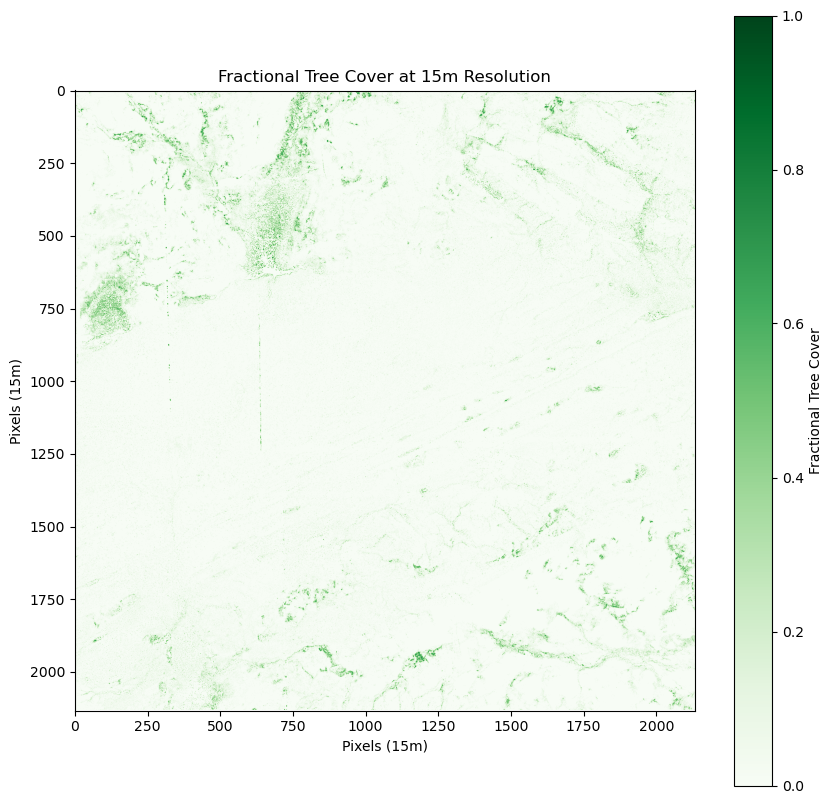

In [210]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.imshow(fractional_cover, cmap="Greens", vmin=0, vmax=1)
plt.colorbar(label="Fractional Tree Cover")
plt.title("Fractional Tree Cover at 15m Resolution")
plt.xlabel("Pixels (15m)")
plt.ylabel("Pixels (15m)")
plt.show()

In [23]:
gdf = gpd.read_file("/mnt/sdc/tree_density_and_coverage/shapefiles/nasa_validation/senegal_cutlines_intersection_with_tiles_sorted_squares_960m_joined_results_new.gpkg")

In [24]:
gdf["positive_tucker_sum"] = gdf["positive_tucker_sum"].astype(str)
gdf["positive_tucker_sum"] = gdf["positive_tucker_sum"].apply(lambda x: x.strip("[]"))
gdf = gdf[gdf["positive_tucker_sum"] != "None"]
gdf = gdf[gdf["positive_tucker_sum"] != ""]
gdf["positive_tucker_sum"] = gdf["positive_tucker_sum"].astype(float)



In [13]:
gdf.columns

Index(['parent_id', 'area', 'early_year', 'late_year', 'year_diff', 'location',
       'location_2', 'positive_ls_sum', 'negative_ls_sum',
       'positive_tucker_sum', 'negative_tucker_sum', 'positive_ls_mean',
       'negative_ls_mean', 'positive_tucker_mean', 'negative_tucker_mean',
       'early_tucker_data_mean', 'late_tucker_data_mean',
       'early_tucker_data_sum', 'late_tucker_data_sum', 'geometry'],
      dtype='object')

In [25]:
gdf = gdf[gdf["early_tucker_data_sum"] != 0]
gdf = gdf[gdf["late_tucker_data_sum"] != 0]
#gdf = gdf[gdf["early_ls_data_sum"] != 0]
#gdf = gdf[gdf["late_ls_data_sum"] != 0]
gdf = gdf[gdf["positive_tucker_mean"] != 0]
gdf = gdf[gdf["positive_ls_mean"] != 0]
gdf = gdf[gdf["negative_tucker_sum"] != 0]
gdf = gdf[gdf["negative_ls_sum"] != 0]

len(gdf)

59782

In [175]:
# calc rmse between early_tucker_data_sum and early_ls_data_sum relative to area of polygon

gdf["early_error_sum"] = gdf["early_tucker_data_sum"] - gdf["early_ls_data_sum"]
gdf["late_error_sum"] = gdf["late_tucker_data_sum"] - gdf["late_ls_data_sum"]
gdf["positive_change_error_sum"] = gdf["positive_tucker_sum"] - gdf["positive_ls_sum"]

# same but for mean
gdf['early_error_mean'] = gdf['early_tucker_data_mean'] - gdf['early_ls_data_mean']
gdf["late_error_mean"] = gdf["late_tucker_data_mean"] - gdf["late_ls_data_mean"]
gdf["positive_change_error_mean"] = gdf["positive_tucker_mean"] - gdf["positive_ls_mean"]







In [176]:
gdf.to_file("/mnt/sdc/tree_density_and_coverage/shapefiles/nasa_validation/senegal_cutlines_intersection_with_tiles_sorted_squares_960m_joined_results_cleaned.gpkg")

In [31]:
gdf_diff = gdf[gdf["year_diff"] >= 20]


In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

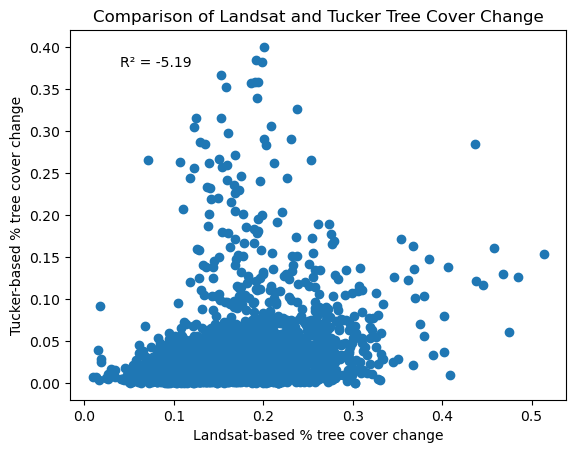

In [ ]:
plt.scatter(gdf_diff["positive_ls_mean"], gdf_diff["positive_tucker_mean"])
plt.xlabel("Landsat-based % tree cover change")
plt.ylabel("Tucker-based % tree cover change")
plt.title("Comparison of Landsat and Tucker Tree Cover Change")
plt.text(0.1, 0.9, f"R² = {r2_score(gdf_diff['positive_ls_mean'], gdf_diff['positive_tucker_mean']):.2f}", transform=plt.gca().transAxes)
plt.show()

Text(0.5, 1.0, 'Validation Predictions vs Targets')

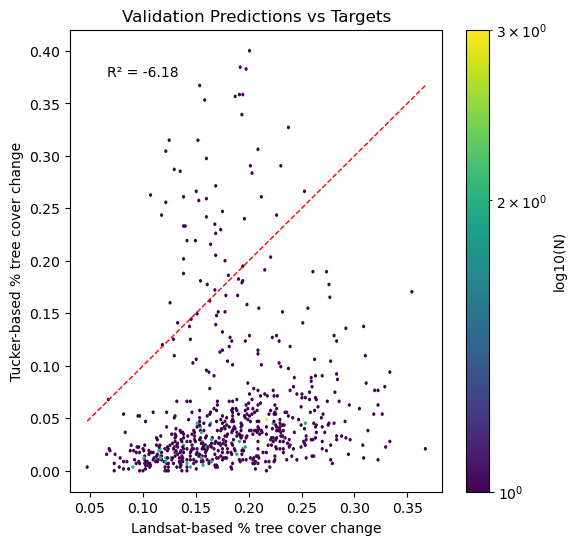

In [37]:
stat = "mean"  # or "sum"
positive = "positive" # or "negative"
plt.figure(figsize=(6,6))
hb = plt.hexbin(gdf_diff[f"{positive}_ls_{stat}"], gdf_diff[f"{positive}_tucker_{stat}"], gridsize=200, cmap="viridis", bins="log")
plt.plot([gdf_diff[f"{positive}_ls_{stat}"].min(), gdf_diff[f"{positive}_ls_{stat}"].max()],
        [gdf_diff[f"{positive}_ls_{stat}"].min(), gdf_diff[f"{positive}_ls_{stat}"].max()],
        "r--", lw=1)
plt.text(0.1, 0.9, f"R² = {r2_score(gdf_diff[f'{positive}_ls_{stat}'], gdf_diff[f'{positive}_tucker_{stat}']):.2f}", transform=plt.gca().transAxes)
plt.colorbar(hb, label="log10(N)")
plt.xlabel("Landsat-based % tree cover change")
plt.ylabel("Tucker-based % tree cover change")
plt.title("Validation Predictions vs Targets")


Text(0.5, 1.0, 'Validation Predictions vs Targets')

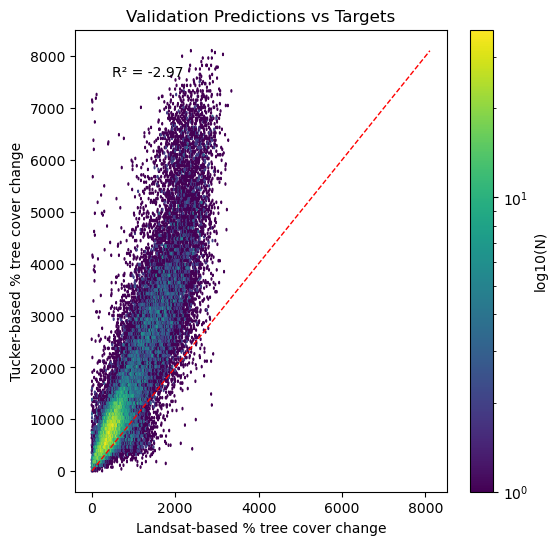

In [179]:
plt.figure(figsize=(6,6))
hb = plt.hexbin(gdf["late_ls_data_sum"], gdf["late_tucker_data_sum"], gridsize=200, cmap="viridis", bins="log")
plt.plot([gdf["late_tucker_data_sum"].min(), gdf["late_tucker_data_sum"].max()],
        [gdf["late_tucker_data_sum"].min(), gdf["late_tucker_data_sum"].max()],
        "r--", lw=1)
plt.text(0.1, 0.9, f"R² = {r2_score(gdf['late_ls_data_sum'], gdf['late_tucker_data_sum']):.2f}", transform=plt.gca().transAxes)
plt.colorbar(hb, label="log10(N)")
plt.xlabel("Landsat-based % tree cover change")
plt.ylabel("Tucker-based % tree cover change")
plt.title("Validation Predictions vs Targets")

In [188]:
# correct bias
# get bias for early and late
early_bias = gdf["early_ls_data_sum"].mean() - gdf["early_tucker_data_sum"].mean()
late_bias = gdf["late_ls_data_sum"].mean() - gdf["late_tucker_data_sum"].mean()
print(f"Early bias: {early_bias}, Late bias: {late_bias}")
gdf["early_ls_data_sum_corrected"] = gdf["early_ls_data_sum"] - early_bias
gdf["late_ls_data_sum_corrected"] = gdf["late_ls_data_sum"] - late_bias

Early bias: -571.4107666015625, Late bias: -910.8272705078125


In [186]:
# remove nan rows
gdf_corrected = gdf.dropna(subset=["early_ls_data_sum_corrected", "late_ls_data_sum_corrected"])
len(gdf_corrected)

0

Text(0.5, 1.0, 'Validation Predictions vs Targets')

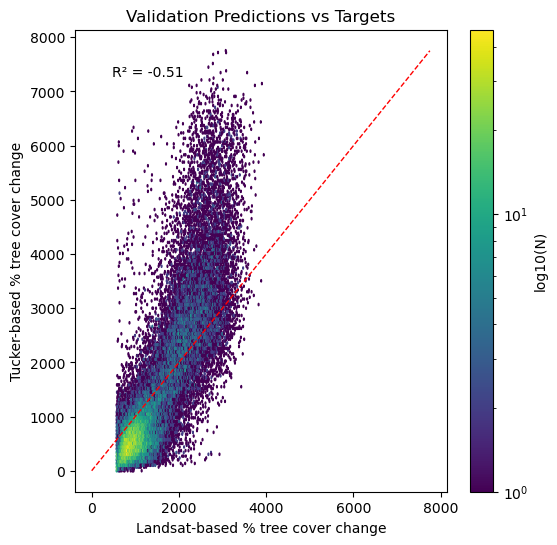

In [189]:

plt.figure(figsize=(6,6))
hb = plt.hexbin(gdf["early_ls_data_sum_corrected"], gdf["early_tucker_data_sum"], gridsize=200, cmap="viridis", bins="log")
plt.plot([gdf["early_tucker_data_sum"].min(), gdf["early_tucker_data_sum"].max()],
        [gdf["early_tucker_data_sum"].min(), gdf["early_tucker_data_sum"].max()],
        "r--", lw=1)
plt.text(0.1, 0.9, f"R² = {r2_score(gdf['early_ls_data_sum_corrected'], gdf['early_tucker_data_sum']):.2f}", transform=plt.gca().transAxes)
plt.colorbar(hb, label="log10(N)")
plt.xlabel("Landsat-based % tree cover change")
plt.ylabel("Tucker-based % tree cover change")
plt.title("Validation Predictions vs Targets")

Text(0.5, 1.0, 'Validation Predictions vs Targets')

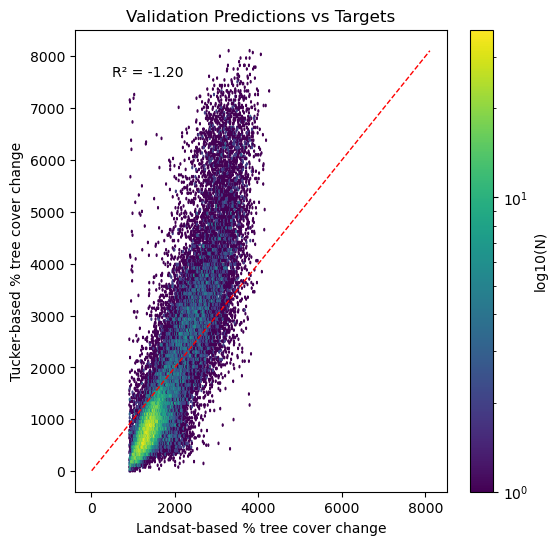

In [190]:
plt.figure(figsize=(6,6))
hb = plt.hexbin(gdf["late_ls_data_sum_corrected"], gdf["late_tucker_data_sum"], gridsize=200, cmap="viridis", bins="log")
plt.plot([gdf["late_tucker_data_sum"].min(), gdf["late_tucker_data_sum"].max()],
        [gdf["late_tucker_data_sum"].min(), gdf["late_tucker_data_sum"].max()],
        "r--", lw=1)
plt.text(0.1, 0.9, f"R² = {r2_score(gdf['late_ls_data_sum_corrected'], gdf['late_tucker_data_sum']):.2f}", transform=plt.gca().transAxes)
plt.colorbar(hb, label="log10(N)")
plt.xlabel("Landsat-based % tree cover change")
plt.ylabel("Tucker-based % tree cover change")
plt.title("Validation Predictions vs Targets")